# Cycling

50 Charge Cycle Profiles for Batch B

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt

import darkdetect

plt.rcdefaults()

if darkdetect.isDark():
    plt.style.use("dark_background")

In [10]:
CYCLING_DATA_DIR = "../Data/Cycling"


def find_cycling_files(dir: str) -> list:
    """
    Find all cycling files in the given directory.
    """
    cycling_files = []
    for file in os.listdir(dir):
        if file.endswith("B.csv") and os.path.isfile(os.path.join(dir, file)):
            cycling_files.append(os.path.join(dir, file))
    return cycling_files


def load_cycling_data(file: str) -> pd.DataFrame:
    """
    Load cycling data from the given file.
    """
    df = pd.read_csv(
        file,
        skiprows=18,
    )

    df.attrs["battery"] = file.split("_")[3]
    if df.attrs["battery"] == "B2X":
        df.attrs["batteryNumber"] = 2
    else:
        df.attrs["batteryNumber"] = int(df.attrs["battery"].split("B")[1])

    return df


cycling_data = sorted(
    [load_cycling_data(file) for file in find_cycling_files(CYCLING_DATA_DIR)],
    key=lambda df: df.attrs["batteryNumber"],
)

/var/folders/3f/ct0r54cd0497vnq7h8jk96q40000gp/T/ipykernel_44366/1009474146.py:19: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/var/folders/3f/ct0r54cd0497vnq7h8jk96q40000gp/T/ipykernel_44366/1009474146.py:19: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/var/folders/3f/ct0r54cd0497vnq7h8jk96q40000gp/T/ipykernel_44366/1009474146.py:19: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/var/folders/3f/ct0r54cd0497vnq7h8jk96q40000gp/T/ipykernel_44366/1009474146.py:19: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/var/folders/3f/ct0r54cd0497vnq7h8jk96q40000gp/T/ipykernel_44366/1009474146.py:19: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df 

In [14]:
# Anomaly for B05. Some negative voltage values. Delete these rows.
# Remove rows with negative voltage values for B05 in cycling_data, in place
for i, df in enumerate(cycling_data):
    if df.attrs["battery"] == "B5":
        cycling_data[i] = df[df["Voltage"] > 0].reset_index(drop=True)

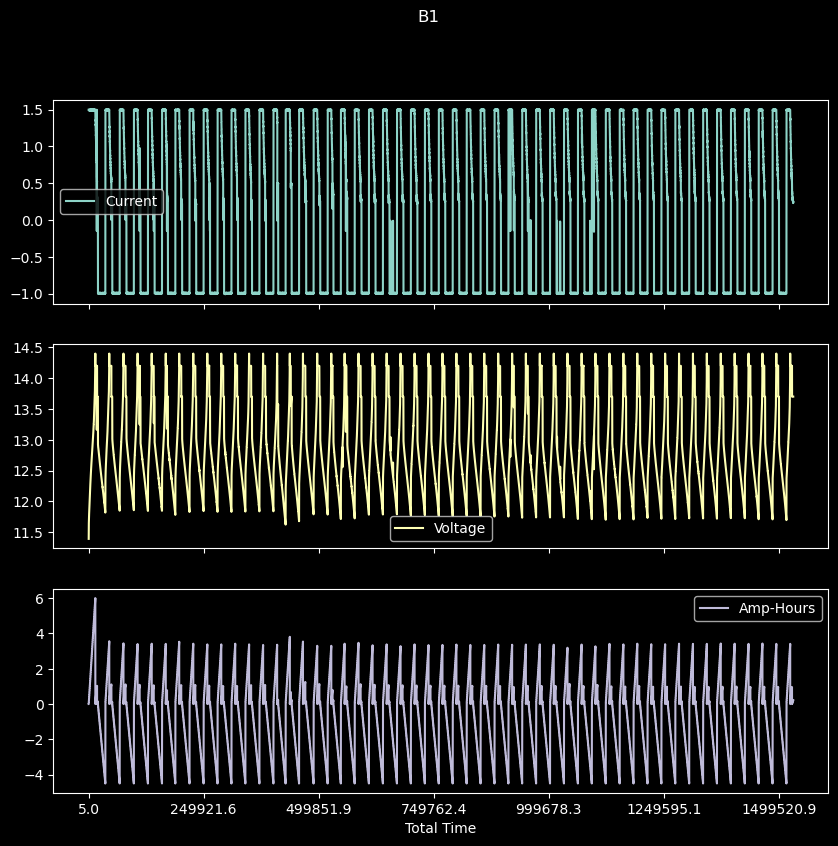

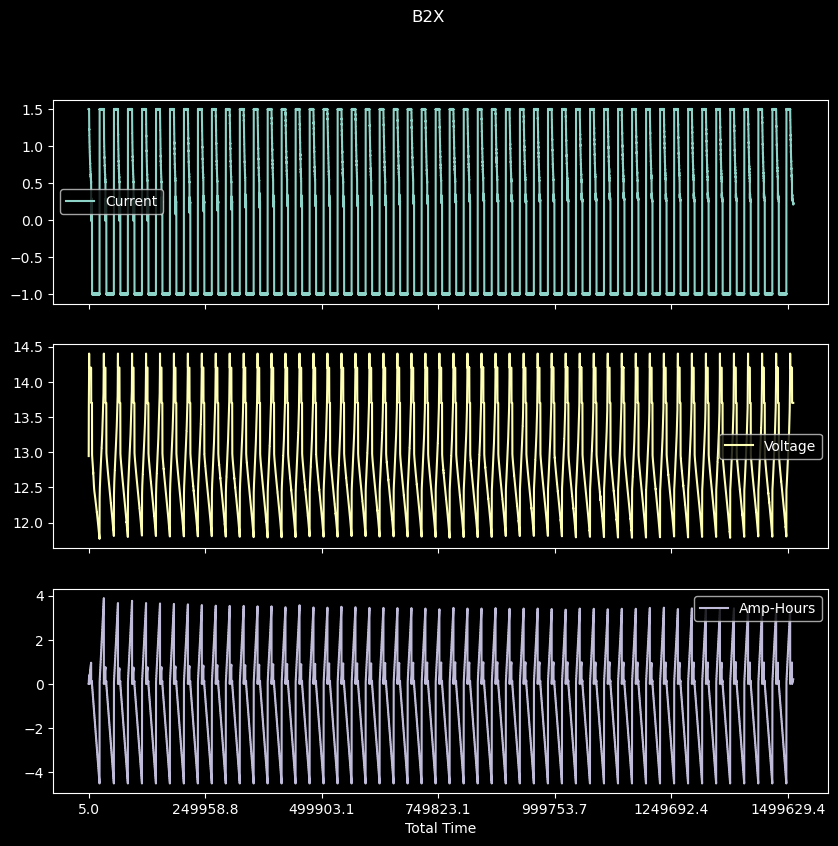

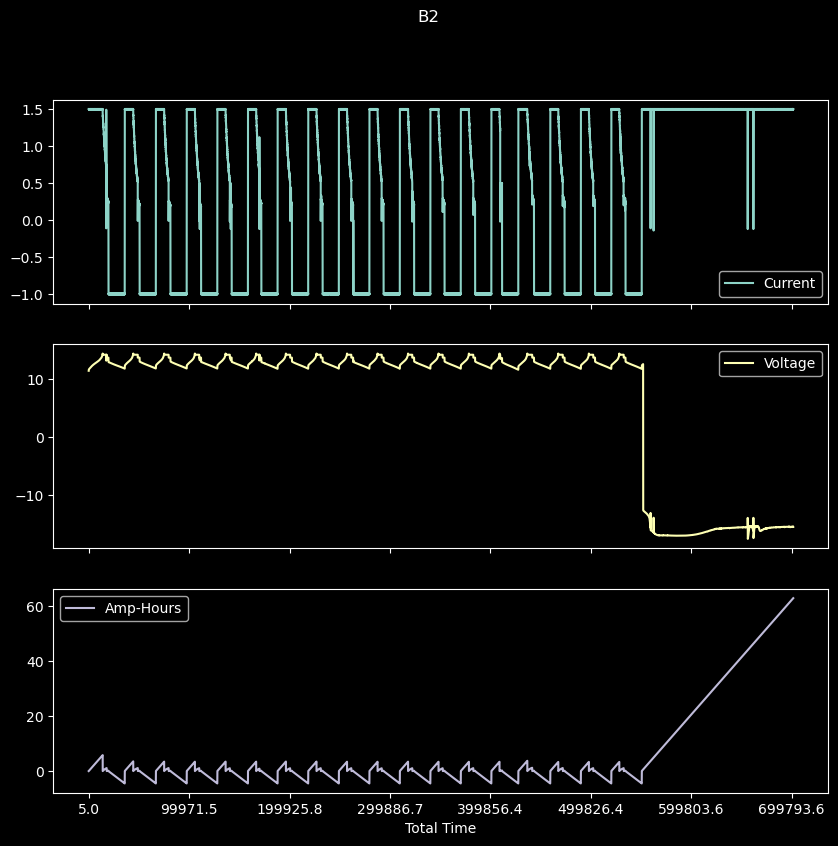

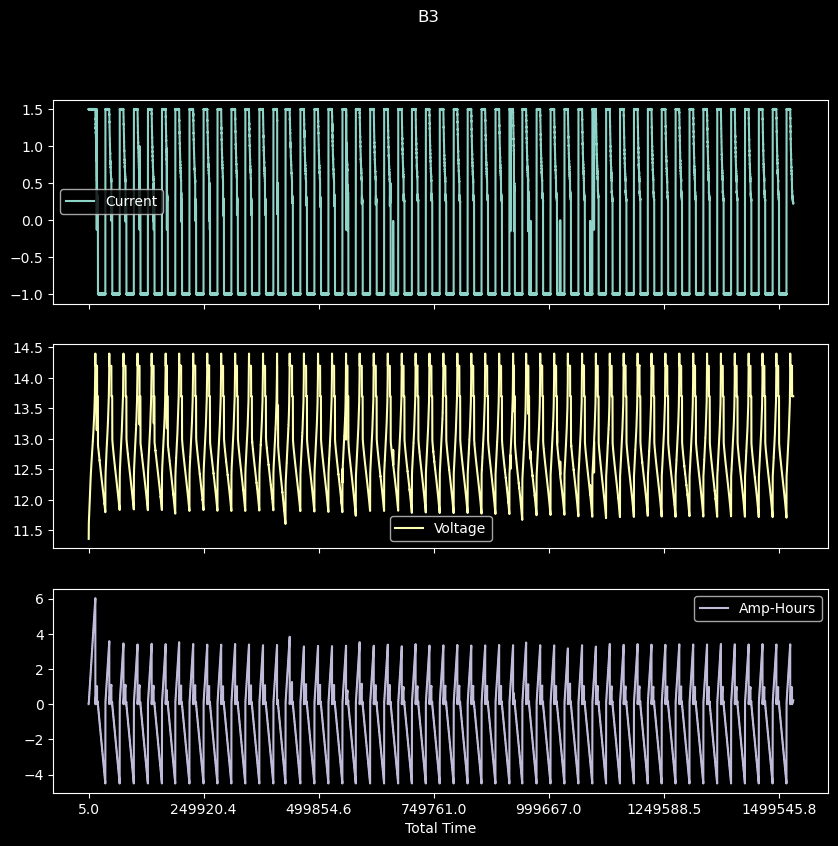

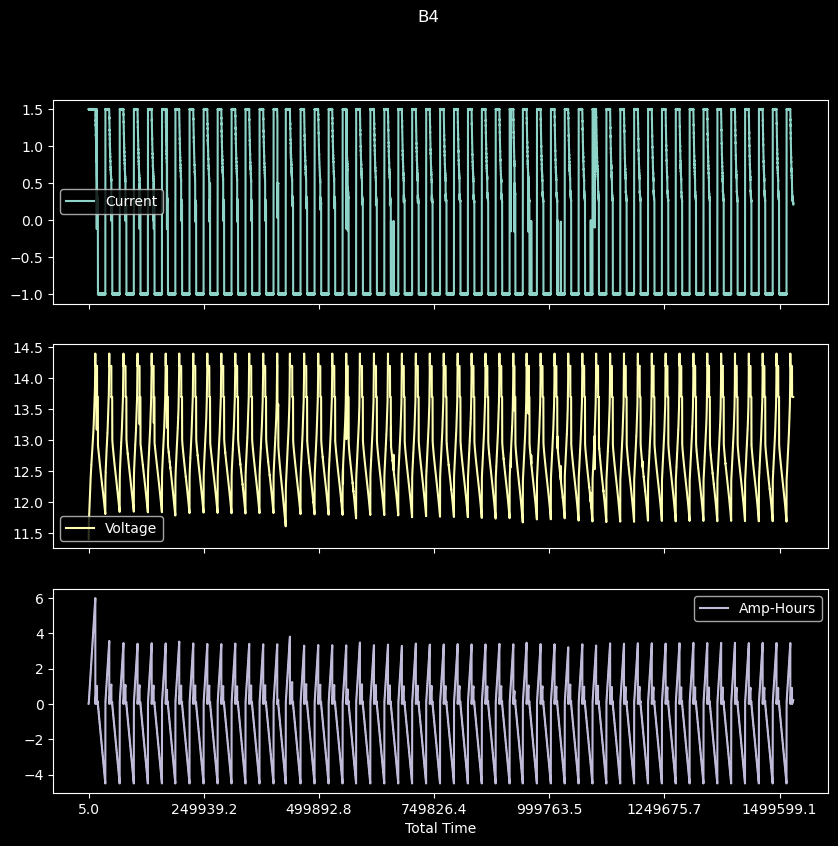

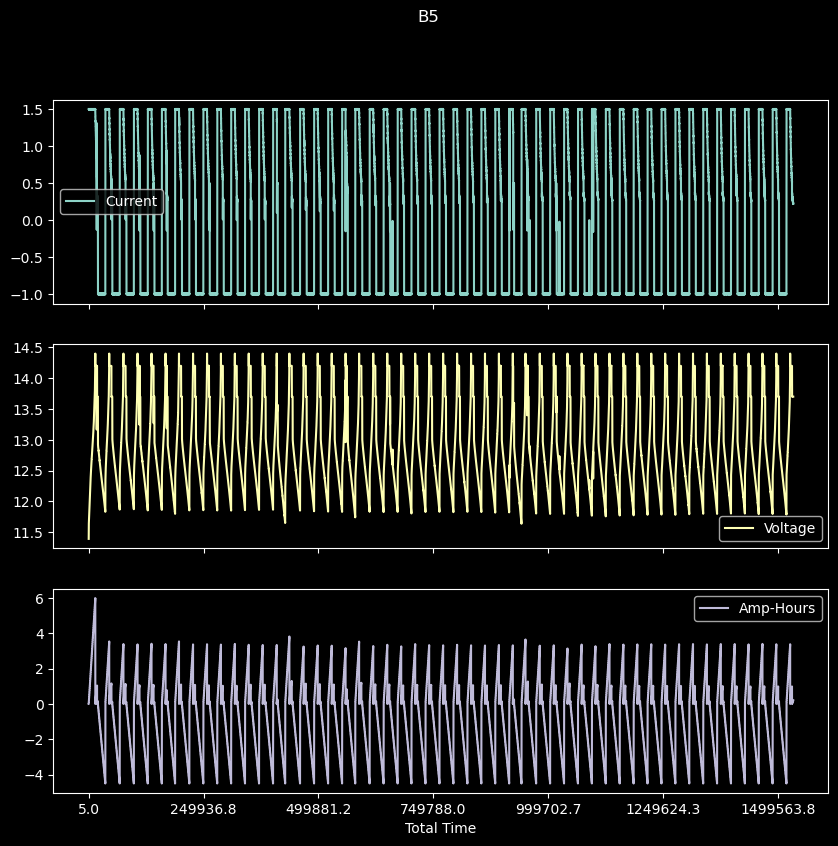

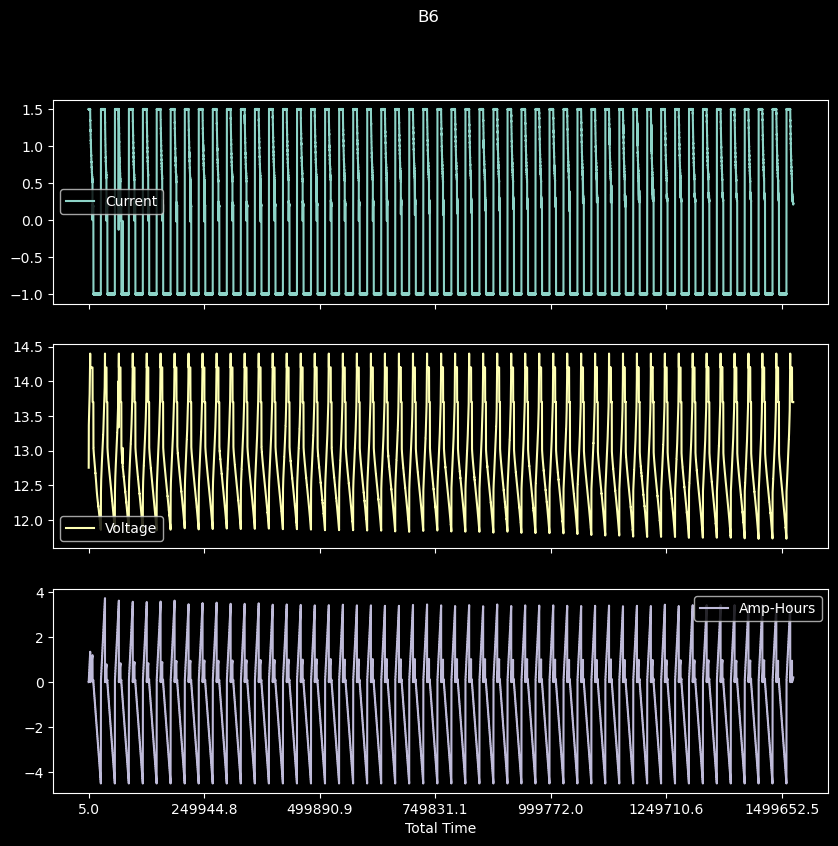

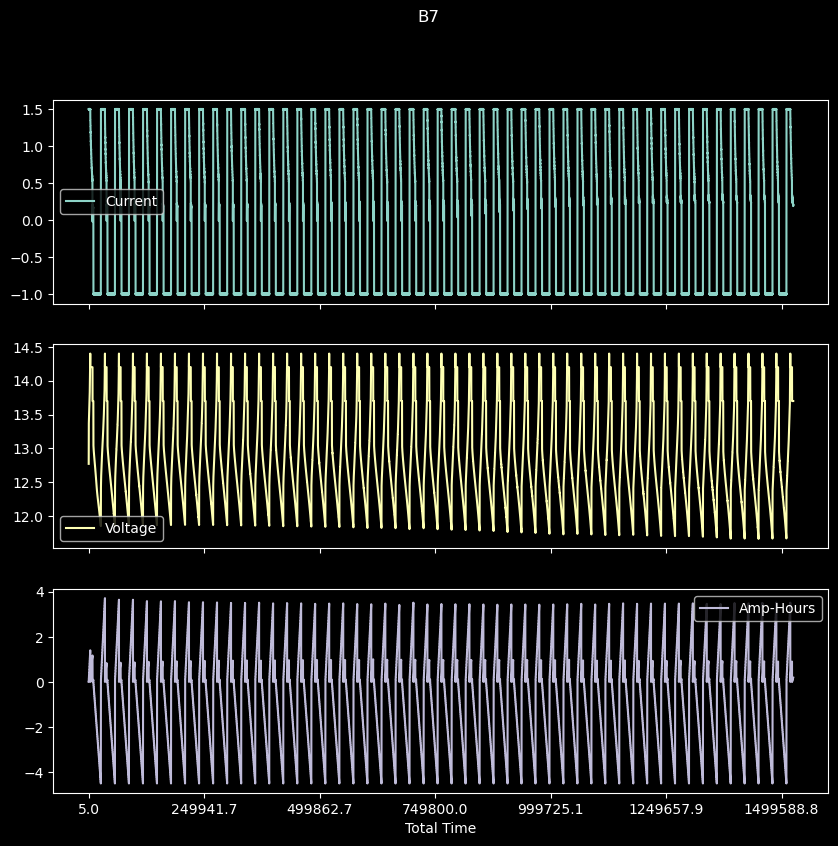

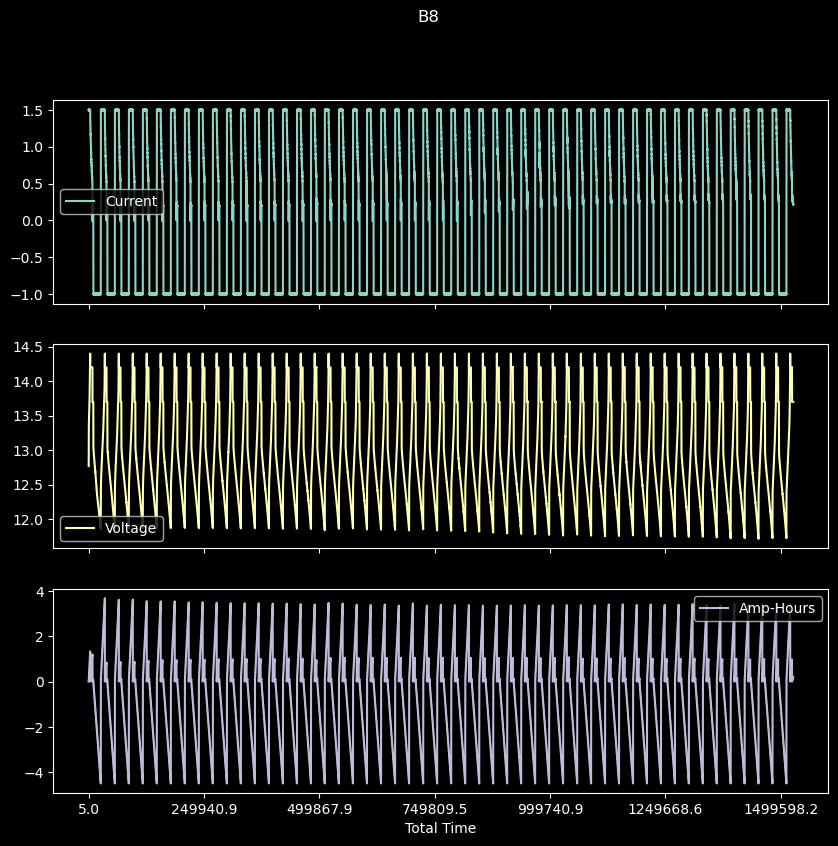

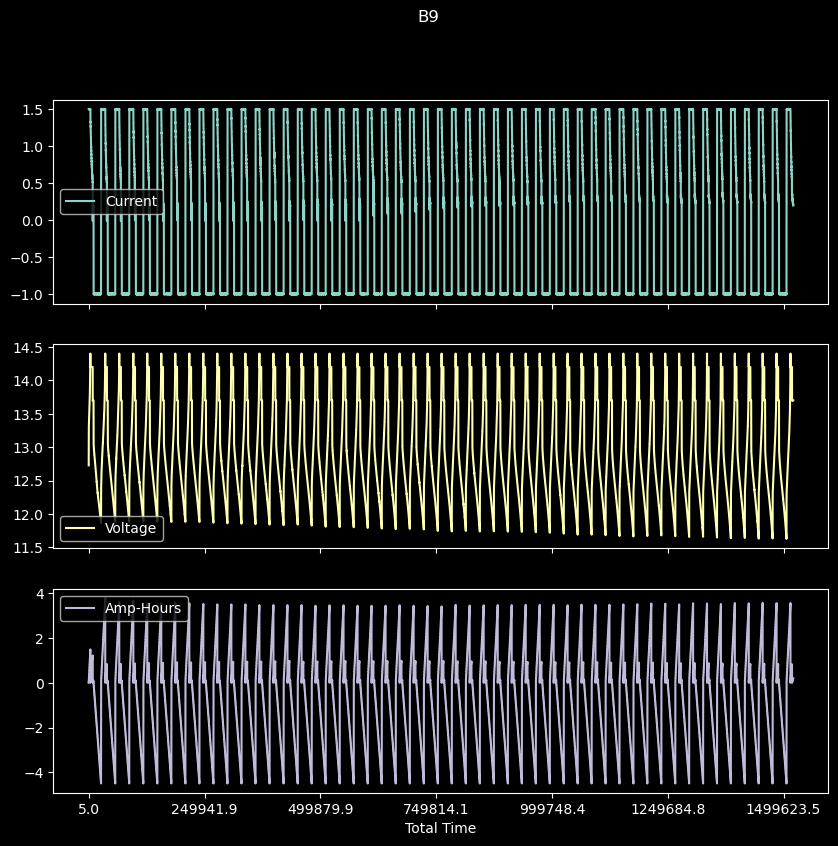

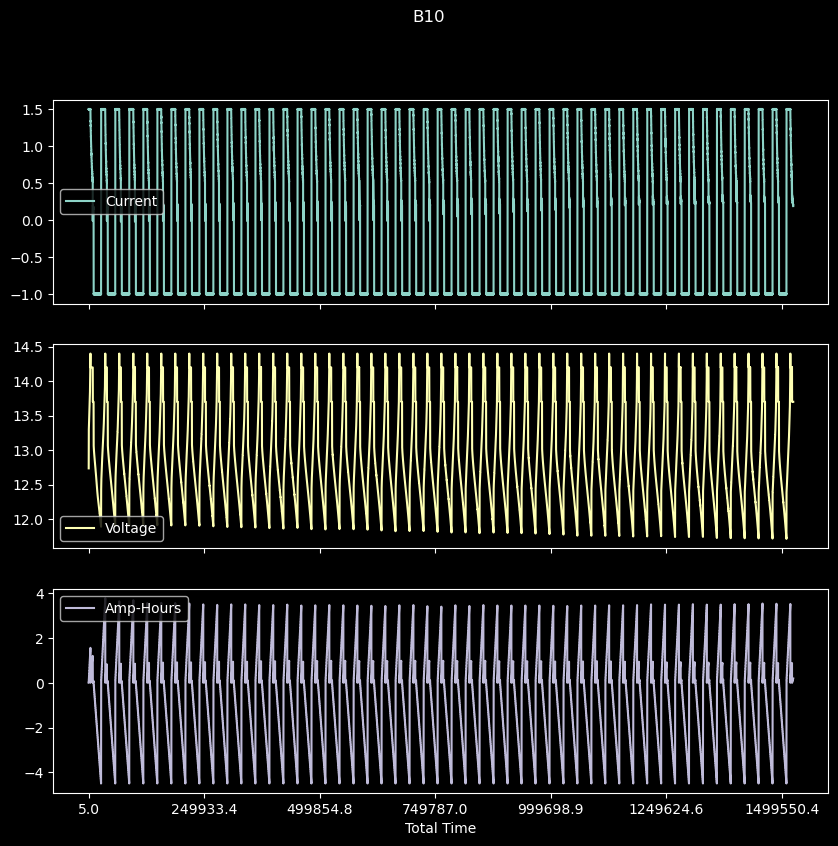

In [15]:
for df in cycling_data:
    df.plot(
        x="Total Time",
        y=[
            "Current",
            "Voltage",
            "Amp-Hours",
        ],
        subplots=True,
        layout=(3, 1),
        figsize=(10, 9),
        title=f"{df.attrs['battery']}",
    )

In [ ]:
cycle_amp_hours = []

for df in cycling_data:
    for cycle in df["Cycle"].unique():
        cycle_df = df[df["Cycle"] == cycle]
        halfCycle_positive = cycle_df[cycle_df["Step"] <= 3]
        halfCycle_negative = cycle_df[cycle_df["Step"] >= 4]

        for halfCycle in [halfCycle_positive, halfCycle_negative]:
            peaks = halfCycle["Amp-Hours"][
                abs(df["Amp-Hours"]) == abs(halfCycle["Amp-Hours"]).max()
            ]
            halfCycle_amp_hours = halfCycle["Amp-Hours"].sum()
            
		cycle_amp_hours.append(
			{
				"battery": df.attrs["battery"],
				"cycle": cycle,
				"charge amp-hours": ,